In [1]:
# Cell 1 — Setup & Data Loading
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Paths
BASE_DIR = Path("..").resolve()
DATA_PATH = BASE_DIR / "data" / "raw" / "nincore_dataset.csv"

# Load
df = pd.read_csv(DATA_PATH)

# Basic info
print("=" * 50)
print("NINCORE DATASET — BASIC INFO")
print("=" * 50)
print(f"Shape          : {df.shape}")
print(f"Rows           : {df.shape[0]:,}")
print(f"Columns        : {df.shape[1]}")
print(f"\nColumn names:\n{df.columns.tolist()}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nNull values    : {df.isnull().sum().sum()}")
print(f"Duplicate NINs : {df['NIN'].duplicated().sum()}")

NINCORE DATASET — BASIC INFO
Shape          : (50000, 20)
Rows           : 50,000
Columns        : 20

Column names:
['NIN', 'Age', 'State_of_Origin', 'Gender', 'NIN_Linkage_Count', 'Login_Frequency', 'Geographic_Velocity', 'Device_Reputation_Score', 'Sector_Conflict_Flag', 'Failed_Auth_Attempts', 'Access_Hour', 'BVN_Status', 'NHIA_Status', 'JAMB_Status', 'FRSC_Status', 'Voter_ID_Status', 'Age_Consistency_Score', 'Name_Mismatch_Flag', 'Sector_Access_Frequency', 'Anomaly_Flag']

Data types:
NIN                          int64
Age                          int64
State_of_Origin                str
Gender                         str
NIN_Linkage_Count            int64
Login_Frequency              int64
Geographic_Velocity        float64
Device_Reputation_Score    float64
Sector_Conflict_Flag         int64
Failed_Auth_Attempts         int64
Access_Hour                  int64
BVN_Status                   int64
NHIA_Status                  int64
JAMB_Status                  int64
FRSC_Status    

CLASS DISTRIBUTION (Anomaly_Flag)
  Legitimate (0) : 47,500  (95.0%)
  Fraudulent (1) : 2,500  (5.0%)

  Total         : 50,000


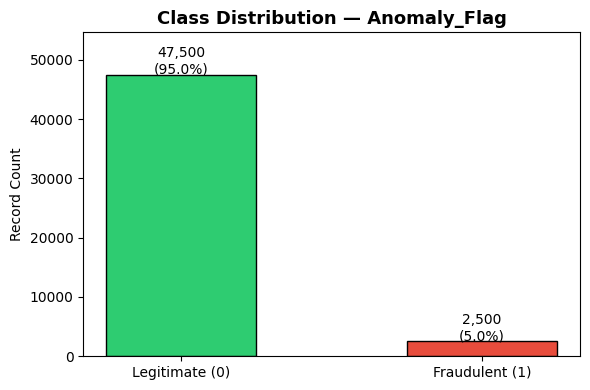

Plot saved.


In [2]:
# Cell 2 — Class Distribution
print("=" * 50)
print("CLASS DISTRIBUTION (Anomaly_Flag)")
print("=" * 50)

counts = df["Anomaly_Flag"].value_counts()
pcts   = df["Anomaly_Flag"].value_counts(normalize=True) * 100

for label, name in [(0, "Legitimate"), (1, "Fraudulent")]:
    print(f"  {name} ({label}) : {counts[label]:,}  ({pcts[label]:.1f}%)")

print(f"\n  Total         : {len(df):,}")

# Plot
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["Legitimate (0)", "Fraudulent (1)"],
       [counts[0], counts[1]],
       color=["#2ecc71", "#e74c3c"], edgecolor="black", width=0.5)

ax.set_title("Class Distribution — Anomaly_Flag", fontsize=13, fontweight="bold")
ax.set_ylabel("Record Count")
for i, v in enumerate([counts[0], counts[1]]):
    ax.text(i, v + 200, f"{v:,}\n({pcts[i]:.1f}%)", ha="center", fontsize=10)

ax.set_ylim(0, counts[0] * 1.15)
plt.tight_layout()
plt.savefig(BASE_DIR / "models" / "evaluation" / "class_distribution.png", dpi=150)
plt.show()
print("Plot saved.")

In [3]:
# Cell 3 — Descriptive Statistics by Class
fraud = df[df["Anomaly_Flag"] == 1]
legit = df[df["Anomaly_Flag"] == 0]

numeric_features = [
    "Age", "NIN_Linkage_Count", "Login_Frequency",
    "Geographic_Velocity", "Device_Reputation_Score",
    "Failed_Auth_Attempts", "Access_Hour",
    "Age_Consistency_Score", "Sector_Access_Frequency"
]

print("=" * 70)
print("DESCRIPTIVE STATISTICS — LEGITIMATE vs FRAUDULENT")
print("=" * 70)

stats = pd.DataFrame({
    "Legit Mean":  legit[numeric_features].mean(),
    "Fraud Mean":  fraud[numeric_features].mean(),
    "Legit Std":   legit[numeric_features].std(),
    "Fraud Std":   fraud[numeric_features].std(),
    "Legit Min":   legit[numeric_features].min(),
    "Fraud Min":   fraud[numeric_features].min(),
    "Legit Max":   legit[numeric_features].max(),
    "Fraud Max":   fraud[numeric_features].max(),
}).round(4)

print(stats.to_string())

DESCRIPTIVE STATISTICS — LEGITIMATE vs FRAUDULENT
                         Legit Mean  Fraud Mean  Legit Std  Fraud Std  Legit Min  Fraud Min  Legit Max  Fraud Max
Age                         48.9843     48.8000    18.2181    17.9885    18.0000    18.0000    80.0000    80.0000
NIN_Linkage_Count            3.1940      3.2132     0.9753     0.9795     1.0000     1.0000     5.0000     5.0000
Login_Frequency              3.0114     10.6312     1.4143     7.5224     1.0000     1.0000     5.0000    30.0000
Geographic_Velocity         39.9738    504.6985    23.1725   770.7936     0.0034     0.0623    79.9998  2991.5248
Device_Reputation_Score      0.7746      0.3693     0.1300     0.2658     0.5500     0.0002     1.0000     0.9000
Failed_Auth_Attempts         1.0035      6.1648     0.8173     6.2593     0.0000     0.0000     2.0000    25.0000
Access_Hour                 14.0182     10.4860     4.9048     7.4084     6.0000     0.0000    22.0000    23.0000
Age_Consistency_Score        0.8749   

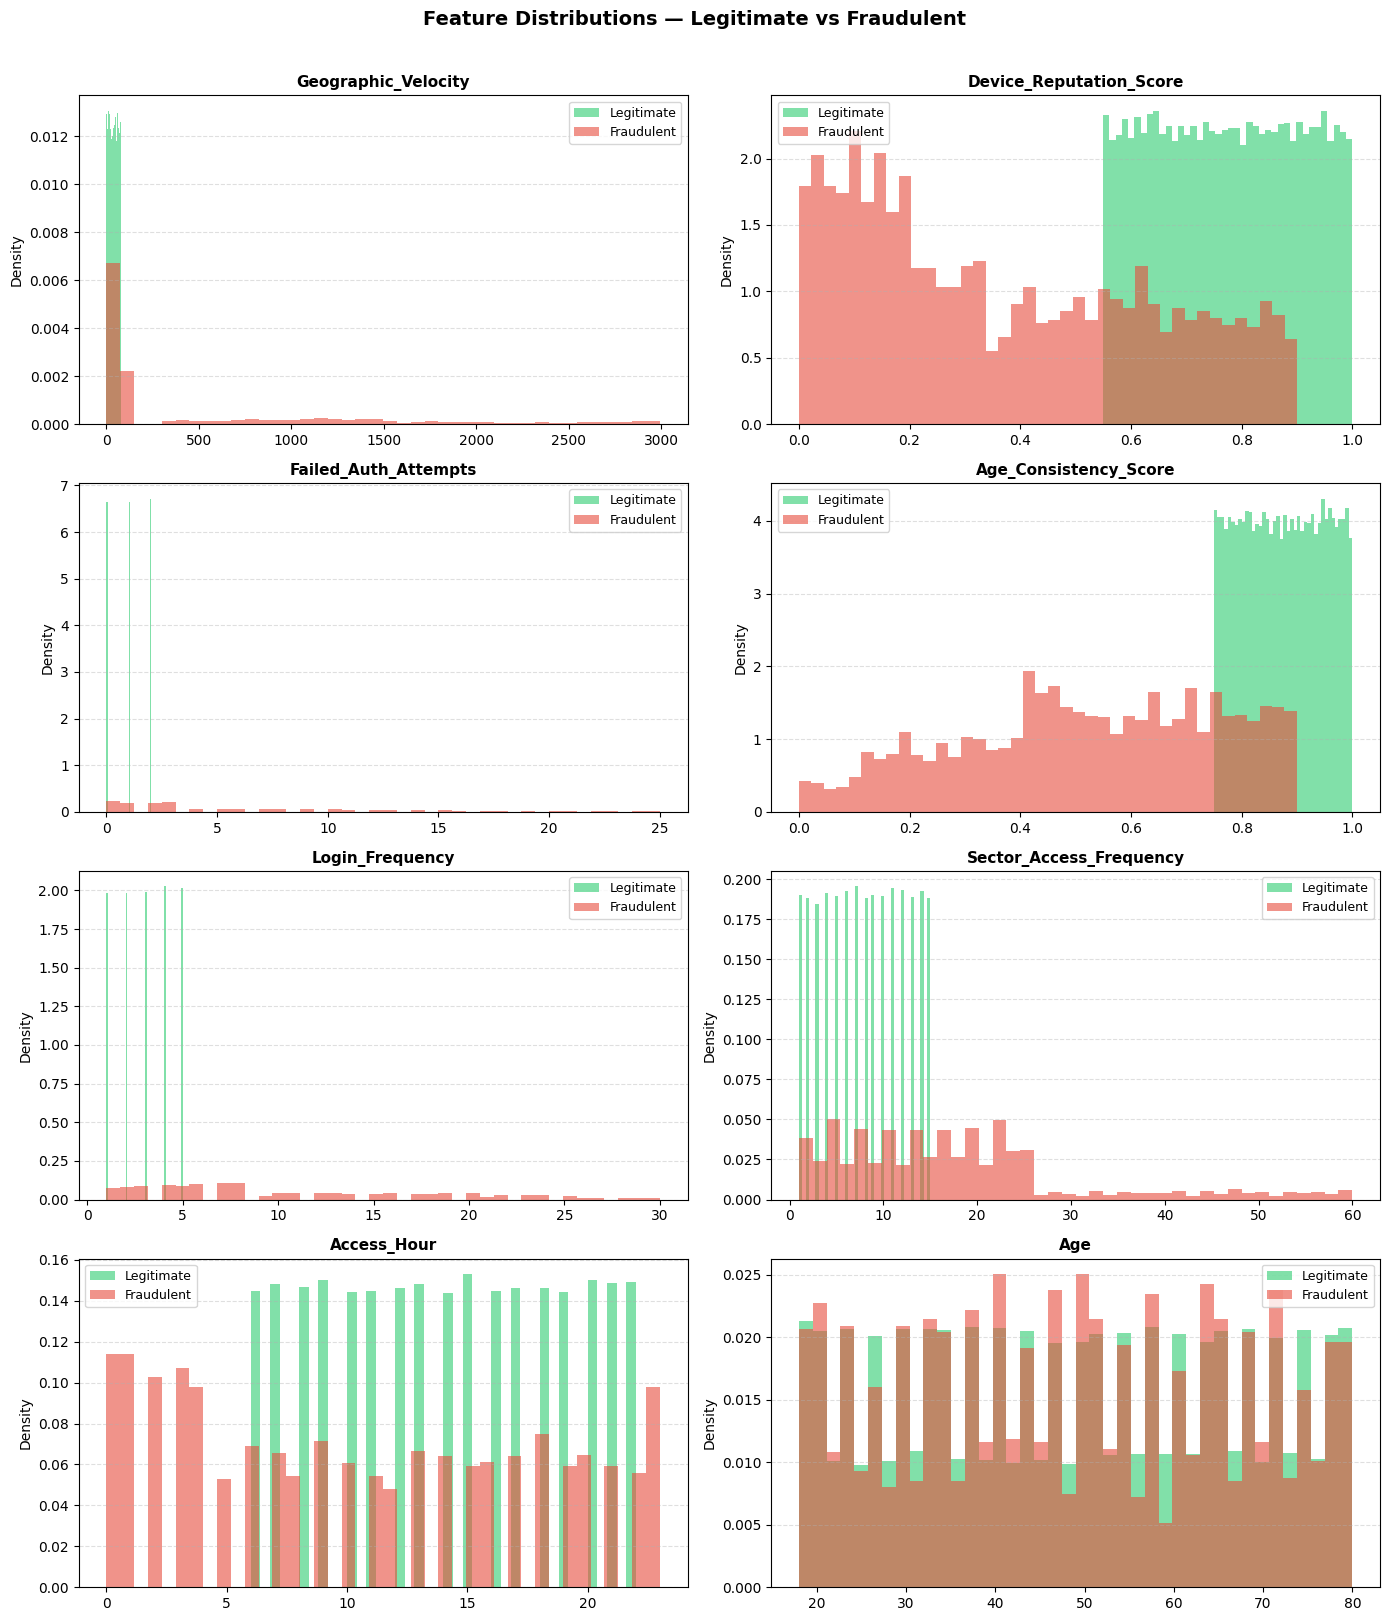

Plot saved.


In [4]:
# Cell 4 — Feature Distribution Plots (Fraud vs Legitimate)
features_to_plot = [
    "Geographic_Velocity", "Device_Reputation_Score",
    "Failed_Auth_Attempts", "Age_Consistency_Score",
    "Login_Frequency", "Sector_Access_Frequency",
    "Access_Hour", "Age"
]

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for i, feat in enumerate(features_to_plot):
    ax = axes[i]
    ax.hist(legit[feat], bins=40, alpha=0.6, color="#2ecc71",
            label="Legitimate", edgecolor="none", density=True)
    ax.hist(fraud[feat], bins=40, alpha=0.6, color="#e74c3c",
            label="Fraudulent", edgecolor="none", density=True)
    ax.set_title(feat, fontsize=11, fontweight="bold")
    ax.set_ylabel("Density")
    ax.legend(fontsize=9)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.suptitle("Feature Distributions — Legitimate vs Fraudulent",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(BASE_DIR / "models" / "evaluation" / "feature_distributions.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved.")

FEATURE CORRELATION WITH Anomaly_Flag (sorted)
  Age_Consistency_Score        -0.6596  ██████████████████████████
  Sector_Conflict_Flag         +0.6353  █████████████████████████
  Login_Frequency              +0.6070  ████████████████████████
  Failed_Auth_Attempts         +0.5727  ██████████████████████
  Name_Mismatch_Flag           +0.5534  ██████████████████████
  Device_Reputation_Score      -0.5337  █████████████████████
  Geographic_Velocity          +0.5035  ████████████████████
  Sector_Access_Frequency      +0.3813  ███████████████
  Access_Hour                  -0.1504  ██████
  Voter_ID_Status              +0.0079  
  NIN_Linkage_Count            +0.0043  
  BVN_Status                   +0.0041  
  Age                          -0.0022  
  NHIA_Status                  -0.0014  
  FRSC_Status                  -0.0012  
  JAMB_Status                  +0.0012  


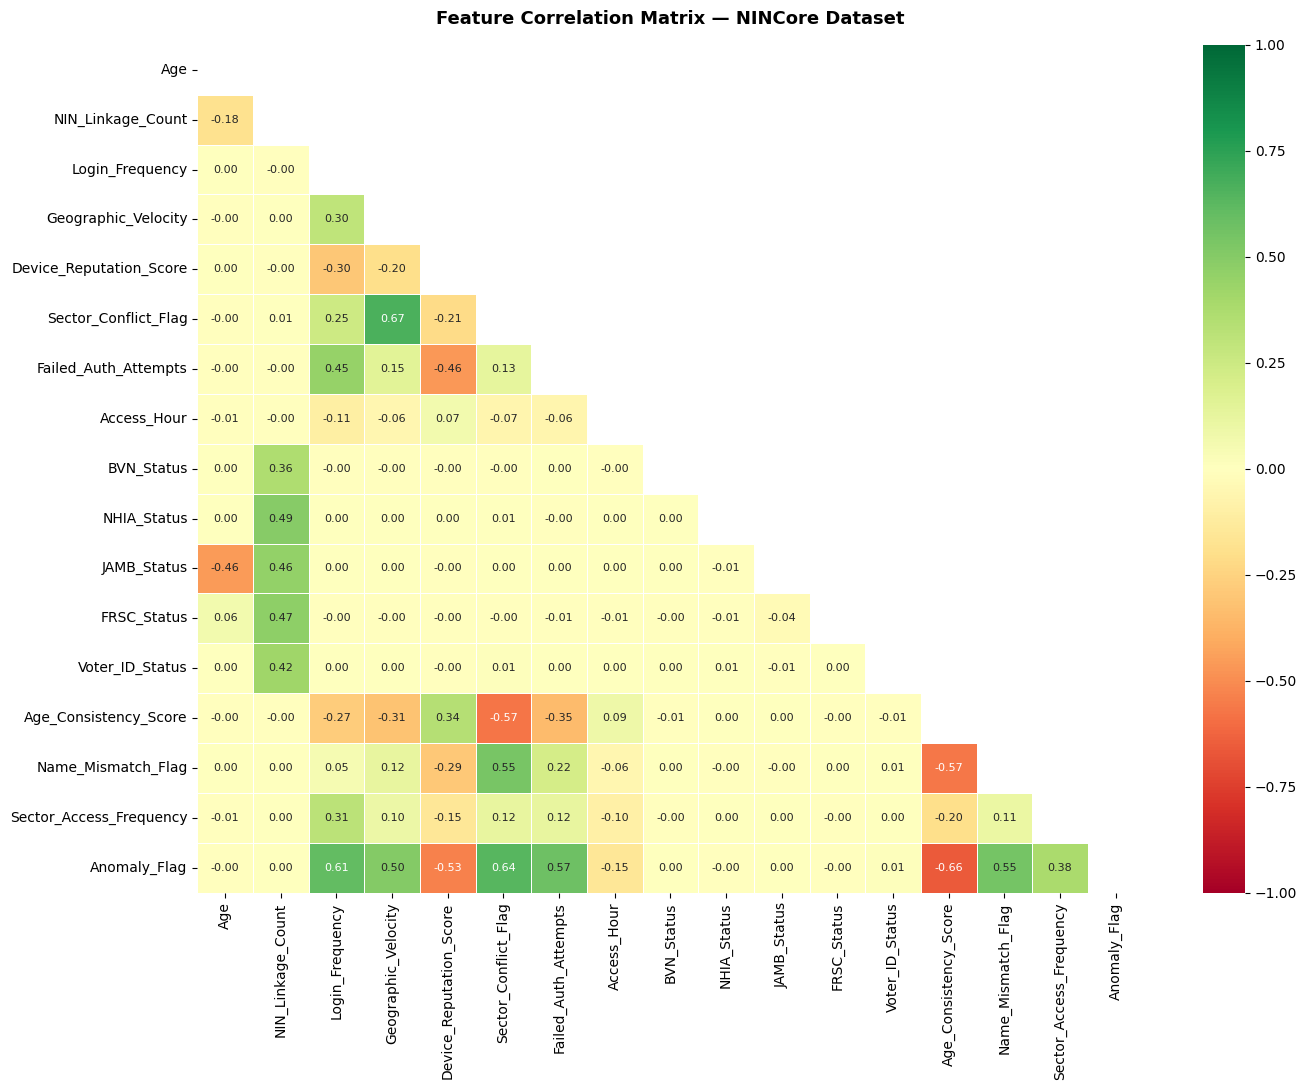

Plot saved.


In [5]:
# Cell 5 — Correlation Heatmap
numeric_cols = [
    "Age", "NIN_Linkage_Count", "Login_Frequency", "Geographic_Velocity",
    "Device_Reputation_Score", "Sector_Conflict_Flag", "Failed_Auth_Attempts",
    "Access_Hour", "BVN_Status", "NHIA_Status", "JAMB_Status", "FRSC_Status",
    "Voter_ID_Status", "Age_Consistency_Score", "Name_Mismatch_Flag",
    "Sector_Access_Frequency", "Anomaly_Flag"
]

corr = df[numeric_cols].corr()

# Correlation with target only
print("=" * 55)
print("FEATURE CORRELATION WITH Anomaly_Flag (sorted)")
print("=" * 55)
target_corr = corr["Anomaly_Flag"].drop("Anomaly_Flag").sort_values(
    key=abs, ascending=False
)
for feat, val in target_corr.items():
    bar = "█" * int(abs(val) * 40)
    print(f"  {feat:<28} {val:+.4f}  {bar}")

# Full heatmap
fig, ax = plt.subplots(figsize=(14, 11))
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f",
    cmap="RdYlGn", center=0, linewidths=0.5,
    annot_kws={"size": 8}, ax=ax,
    vmin=-1, vmax=1
)
ax.set_title("Feature Correlation Matrix — NINCore Dataset",
             fontsize=13, fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig(BASE_DIR / "models" / "evaluation" / "correlation_heatmap.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved.")

SECTORAL FLAG ANALYSIS

  Overall linkage rates (% of all 50,000 records):
    BVN_Status          : 85.3%
    NHIA_Status         : 60.3%
    JAMB_Status         : 32.5%
    FRSC_Status         : 63.0%
    Voter_ID_Status     : 78.1%

  Linkage rates — LEGITIMATE records:
    BVN_Status          : 85.3%
    NHIA_Status         : 60.3%
    JAMB_Status         : 32.5%
    FRSC_Status         : 63.0%
    Voter_ID_Status     : 78.0%

  Linkage rates — FRAUDULENT records:
    BVN_Status          : 85.9%
    NHIA_Status         : 60.0%
    JAMB_Status         : 32.8%
    FRSC_Status         : 62.8%
    Voter_ID_Status     : 79.5%

  NIN_Linkage_Count distribution:
NIN_Linkage_Count     1     2      3      4     5
Anomaly_Flag                                     
0                  2088  8909  17905  14894  3704
1                   114   443    943    796   204


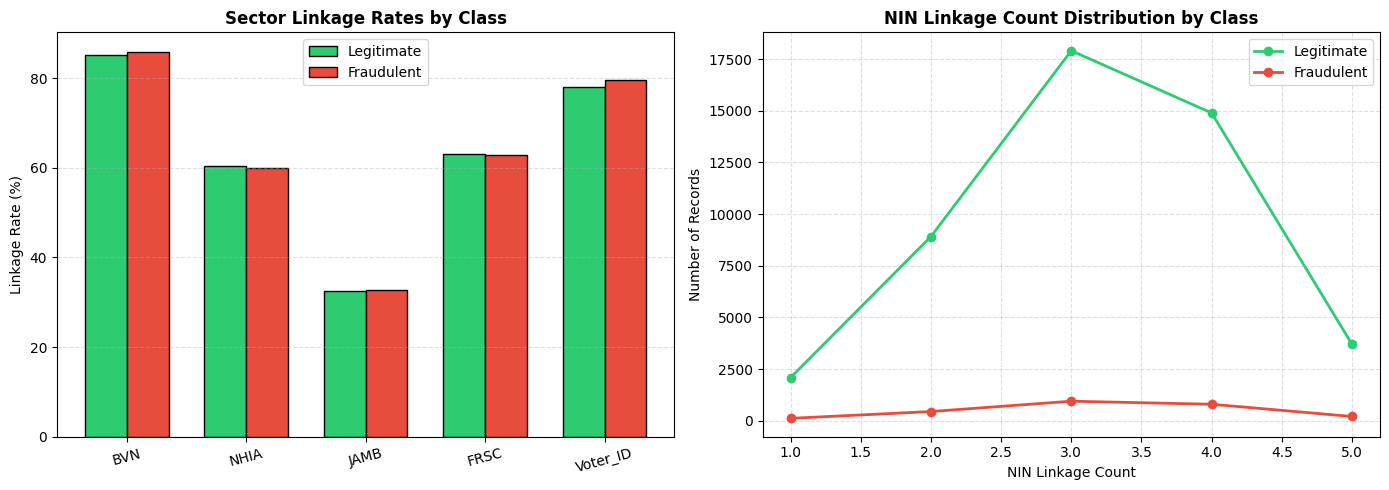

Plot saved.


In [6]:
# Cell 6 — Sectoral Flag Analysis
sector_flags = ["BVN_Status", "NHIA_Status", "JAMB_Status",
                "FRSC_Status", "Voter_ID_Status"]

print("=" * 60)
print("SECTORAL FLAG ANALYSIS")
print("=" * 60)

print("\n  Overall linkage rates (% of all 50,000 records):")
for col in sector_flags:
    rate = df[col].mean() * 100
    print(f"    {col:<20}: {rate:.1f}%")

print("\n  Linkage rates — LEGITIMATE records:")
for col in sector_flags:
    rate = legit[col].mean() * 100
    print(f"    {col:<20}: {rate:.1f}%")

print("\n  Linkage rates — FRAUDULENT records:")
for col in sector_flags:
    rate = fraud[col].mean() * 100
    print(f"    {col:<20}: {rate:.1f}%")

print("\n  NIN_Linkage_Count distribution:")
print(df.groupby("Anomaly_Flag")["NIN_Linkage_Count"]
      .value_counts().unstack(fill_value=0).to_string())

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grouped bar — linkage rates by class
rates_legit = [legit[col].mean() * 100 for col in sector_flags]
rates_fraud = [fraud[col].mean() * 100 for col in sector_flags]
x = np.arange(len(sector_flags))
w = 0.35
labels = [c.replace("_Status", "") for c in sector_flags]

axes[0].bar(x - w/2, rates_legit, w, label="Legitimate",
            color="#2ecc71", edgecolor="black")
axes[0].bar(x + w/2, rates_fraud, w, label="Fraudulent",
            color="#e74c3c", edgecolor="black")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, rotation=15)
axes[0].set_ylabel("Linkage Rate (%)")
axes[0].set_title("Sector Linkage Rates by Class", fontweight="bold")
axes[0].legend()
axes[0].grid(axis="y", linestyle="--", alpha=0.4)

# NIN_Linkage_Count distribution by class
for flag, color, label in [(0,"#2ecc71","Legitimate"),(1,"#e74c3c","Fraudulent")]:
    subset = df[df["Anomaly_Flag"] == flag]["NIN_Linkage_Count"].value_counts().sort_index()
    axes[1].plot(subset.index, subset.values, marker="o",
                 color=color, label=label, linewidth=2)
axes[1].set_xlabel("NIN Linkage Count")
axes[1].set_ylabel("Number of Records")
axes[1].set_title("NIN Linkage Count Distribution by Class", fontweight="bold")
axes[1].legend()
axes[1].grid(linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig(BASE_DIR / "models" / "evaluation" / "sectoral_analysis.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved.")

STATE DISTRIBUTION — Top 10 by Record Count
                 Total  Legitimate  Fraudulent  Fraud_Rate_%
State_of_Origin                                             
Abia              1395        1339          56          4.01
Adamawa              0        1299          74           inf
Akwa Ibom            0        1275          60           inf
Anambra              0        1287          77           inf
Bauchi               0        1275          61           inf
Bayelsa              0        1239          68           inf
Benue                0        1251          77           inf
Borno                0        1266          91           inf
Cross River       1378        1315          63          4.57
Delta             1405        1335          70          4.98
Ebonyi               0        1272          61           inf
Edo                  0        1238          63           inf
Ekiti                0        1234          69           inf
Enugu                0        1246       

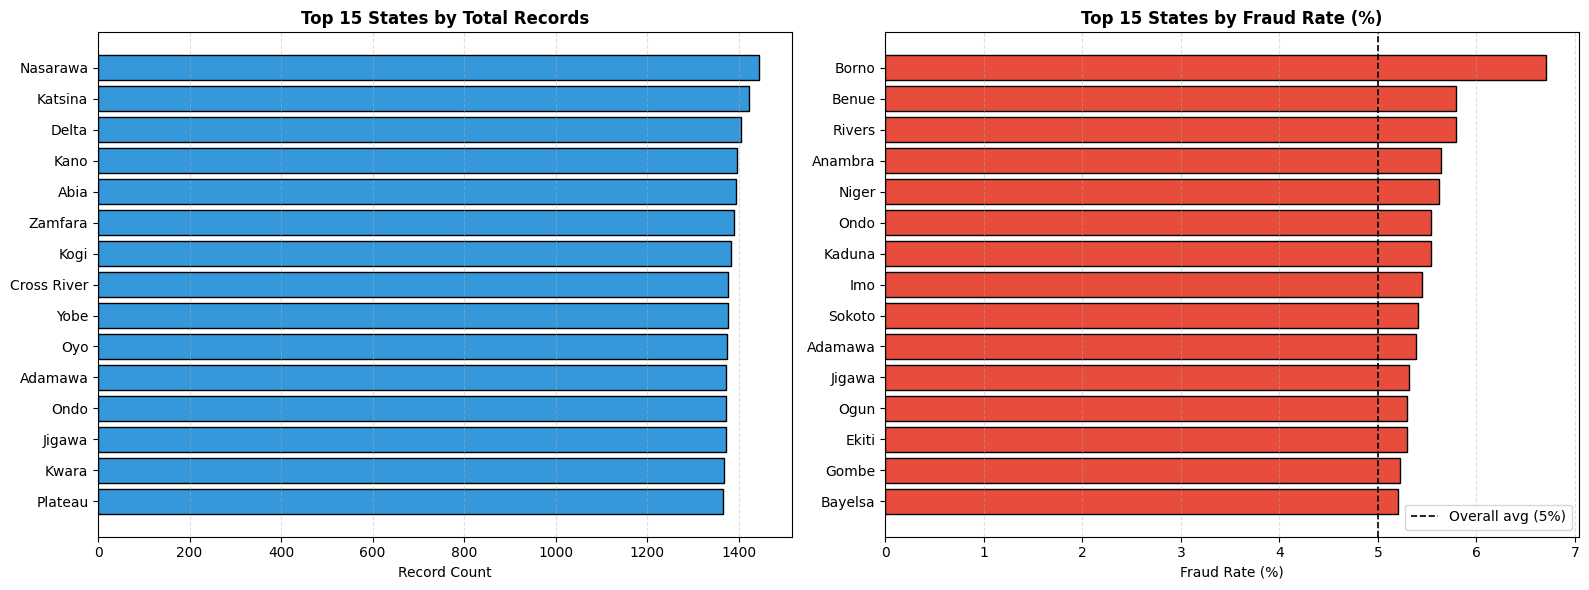

Plot saved.


In [7]:
# Cell 7 — Geographic Distribution by Class
print("=" * 60)
print("STATE DISTRIBUTION — Top 10 by Record Count")
print("=" * 60)

state_total = df["State_of_Origin"].value_counts().head(10)
state_fraud = fraud["State_of_Origin"].value_counts()
state_legit = legit["State_of_Origin"].value_counts()

state_df = pd.DataFrame({
    "Total":      state_total,
    "Legitimate": state_legit,
    "Fraudulent": state_fraud,
}).fillna(0).astype(int)
state_df["Fraud_Rate_%"] = (
    state_df["Fraudulent"] / state_df["Total"] * 100
).round(2)

print(state_df.to_string())

print(f"\n  Total states represented : {df['State_of_Origin'].nunique()}")
print(f"  Most represented state   : {df['State_of_Origin'].value_counts().idxmax()}")
print(f"  Least represented state  : {df['State_of_Origin'].value_counts().idxmin()}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 15 states by total records
top15 = df["State_of_Origin"].value_counts().head(15)
axes[0].barh(top15.index[::-1], top15.values[::-1],
             color="#3498db", edgecolor="black")
axes[0].set_xlabel("Record Count")
axes[0].set_title("Top 15 States by Total Records", fontweight="bold")
axes[0].grid(axis="x", linestyle="--", alpha=0.4)

# Fraud rate by state (all states)
fraud_rate = (
    df.groupby("State_of_Origin")["Anomaly_Flag"].mean() * 100
).sort_values(ascending=False).head(15)
axes[1].barh(fraud_rate.index[::-1], fraud_rate.values[::-1],
             color="#e74c3c", edgecolor="black")
axes[1].set_xlabel("Fraud Rate (%)")
axes[1].set_title("Top 15 States by Fraud Rate (%)", fontweight="bold")
axes[1].axvline(x=5.0, color="black", linestyle="--",
                linewidth=1.2, label="Overall avg (5%)")
axes[1].legend()
axes[1].grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig(BASE_DIR / "models" / "evaluation" / "geographic_distribution.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved.")

BINARY FLAG ANALYSIS

  Flag prevalence by class:

  Flag                       Legit=1 %  Fraud=1 %  Overall %
  ----------------------------------------------------------
  Sector_Conflict_Flag            0.0%      41.6%       2.1%
  Name_Mismatch_Flag              0.0%      31.7%       1.6%
  BVN_Status                     85.3%      85.9%      85.3%
  NHIA_Status                    60.3%      60.0%      60.3%
  JAMB_Status                    32.5%      32.8%      32.5%
  FRSC_Status                    63.0%      62.8%      63.0%
  Voter_ID_Status                78.0%      79.5%      78.1%

  Crosstab — Sector_Conflict_Flag vs Anomaly_Flag:
                 Legitimate  Fraudulent  Total
No Conflict (0)       47500        1460  48960
Conflict (1)              0        1040   1040
Total                 47500        2500  50000

  Crosstab — Name_Mismatch_Flag vs Anomaly_Flag:
                 Legitimate  Fraudulent  Total
No Mismatch (0)       47500        1707  49207
Mismatch (1)    

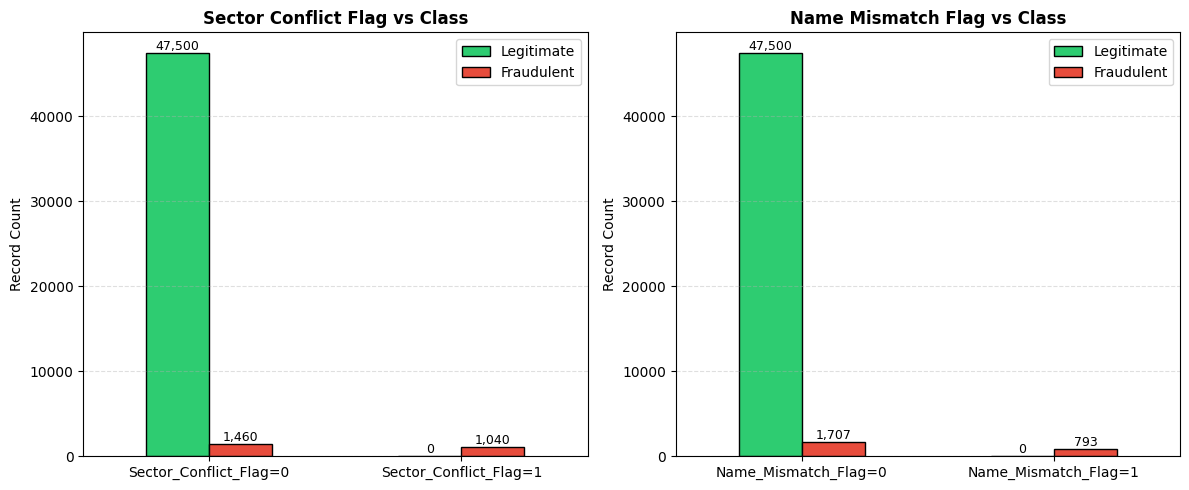

Plot saved.


In [8]:
# Cell 8 — Binary Flag Cross-Tabulation
print("=" * 60)
print("BINARY FLAG ANALYSIS")
print("=" * 60)

binary_flags = [
    "Sector_Conflict_Flag", "Name_Mismatch_Flag",
    "BVN_Status", "NHIA_Status", "JAMB_Status",
    "FRSC_Status", "Voter_ID_Status"
]

print("\n  Flag prevalence by class:\n")
print(f"  {'Flag':<25} {'Legit=1 %':>10} {'Fraud=1 %':>10} {'Overall %':>10}")
print("  " + "-" * 58)
for flag in binary_flags:
    l_rate = legit[flag].mean() * 100
    f_rate = fraud[flag].mean() * 100
    o_rate = df[flag].mean() * 100
    print(f"  {flag:<25} {l_rate:>9.1f}% {f_rate:>9.1f}% {o_rate:>9.1f}%")

# Cross-tab: Sector_Conflict_Flag x Anomaly_Flag
print("\n  Crosstab — Sector_Conflict_Flag vs Anomaly_Flag:")
ct1 = pd.crosstab(df["Sector_Conflict_Flag"], df["Anomaly_Flag"],
                  margins=True, margins_name="Total")
ct1.columns = ["Legitimate", "Fraudulent", "Total"]
ct1.index   = ["No Conflict (0)", "Conflict (1)", "Total"]
print(ct1.to_string())

# Cross-tab: Name_Mismatch_Flag x Anomaly_Flag
print("\n  Crosstab — Name_Mismatch_Flag vs Anomaly_Flag:")
ct2 = pd.crosstab(df["Name_Mismatch_Flag"], df["Anomaly_Flag"],
                  margins=True, margins_name="Total")
ct2.columns = ["Legitimate", "Fraudulent", "Total"]
ct2.index   = ["No Mismatch (0)", "Mismatch (1)", "Total"]
print(ct2.to_string())

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, flag, title in [
    (axes[0], "Sector_Conflict_Flag", "Sector Conflict Flag"),
    (axes[1], "Name_Mismatch_Flag",   "Name Mismatch Flag"),
]:
    data = df.groupby([flag, "Anomaly_Flag"]).size().unstack(fill_value=0)
    data.columns = ["Legitimate", "Fraudulent"]
    data.index   = [f"{flag}=0", f"{flag}=1"]
    data.plot(kind="bar", ax=ax, color=["#2ecc71", "#e74c3c"],
              edgecolor="black", rot=0)
    ax.set_title(f"{title} vs Class", fontweight="bold")
    ax.set_ylabel("Record Count")
    ax.legend()
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    for p in ax.patches:
        ax.annotate(f"{int(p.get_height()):,}",
                    (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig(BASE_DIR / "models" / "evaluation" / "binary_flag_analysis.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved.")